In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../utils")
import data_io

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import skeliner as sk
from matplotlib import pyplot as plt

In [3]:
config = data_io.get_data_config()
version = config.get("version", None)
file_path = data_io.get_file_path(config)
assert os.path.isfile(file_path), file_path
fig_dir = f'../figures/proofreading/v{version}'
os.makedirs(fig_dir, exist_ok=True)

### Load final DF

In [4]:
df_all = pd.read_parquet(file_path)

#merge status columns
df_all.loc[~df_all.Status.isna(),'status'] = df_all.Status[~df_all.Status.isna()]
print(sum(df_all.status.isin(['Complete', 'Complete (cut off)'])),'proofread cells')

#merge row column
df_all.loc[:,'row_merged'] = None
is_bcsheet = df_all['row'].isna()
df_all.loc[is_bcsheet,'row_merged'] = df_all.loc[is_bcsheet,'Index BC Sheet']
df_all.loc[~is_bcsheet,'row_merged'] = df_all.loc[~is_bcsheet,'row']

## subset to proofread
df_proofread = df_all[df_all.status.isin(['Complete', 'Complete (cut off)'])].copy()
df_proofread.shape

25908 proofread cells


(25908, 401)

In [5]:
def match_csv_files(df: pd.DataFrame, directory: str) -> pd.DataFrame:
    id_to_file = {}
    #go through files in order
    for f in sorted(os.listdir(directory)):
        #for all csvs with exactly 5 parts in the filename
        if f.endswith(".csv") and (parts := f.split("_")) and len(parts) == 5:
            #if ID (=parts[3]) is not yet in dict, add the path. otherwise ignore
            id_to_file.setdefault(parts[3], os.path.join(directory, f))
    #mat back to DF based on index=ID
    df["changelog_path"] = df.index.map(id_to_file)
    return df

In [6]:
df_proofread = match_csv_files(df=df_proofread,directory='../data/track_proofreading/changelogs_csv')

print(f"Filtering out {sum(df_proofread['changelog_path'].isna())} cells for which we did not get a changelog")
df_proofread = df_proofread.loc[~df_proofread['changelog_path'].isna(),:].copy()

df_proofread.shape

Filtering out 2 cells for which we did not get a changelog


(25906, 402)

### Divide ACs in NF MF WF

NF/MF/WF borders in um: [ 70.10541235 314.19066029]


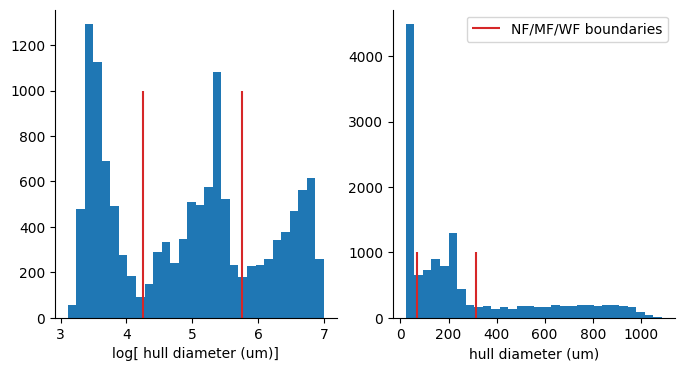

In [7]:
df_acs = df_proofread[df_proofread.cellclass_final=='AC']
plt.figure(figsize=(8,4))

log_thresholds = [4.25,5.75]
ac_subclass_thresholds = np.exp(log_thresholds)
print('NF/MF/WF borders in um:',ac_subclass_thresholds)

plt.subplot(121)
plt.hist(df_acs['log_hull_diameter'],bins=30)
plt.vlines(x=log_thresholds,ymin=0,ymax=1000,colors='tab:red')
plt.xlabel('log[ hull diameter (um)]')

plt.subplot(122)
plt.hist(np.exp(df_acs['log_hull_diameter']),bins=30)
plt.vlines(x=ac_subclass_thresholds,ymin=0,ymax=1000,colors='tab:red',label='NF/MF/WF boundaries')
plt.legend()
plt.xlabel('hull diameter (um)')

sns.despine()

In [8]:
#divide into subclasses
df_proofread['AC_subclass'] = pd.cut(df_proofread['hull_diameter'], bins=[-np.inf, *ac_subclass_thresholds, np.inf], labels=['NF AC','MF AC','WF AC'],)
df_proofread['class_incl_subclasses'] = df_proofread['cellclass_final'].copy()
df_proofread.loc[df_proofread['cellclass_final']=='AC','class_incl_subclasses'] = df_proofread.loc[df_proofread['cellclass_final']=='AC','AC_subclass']

### Read proofreading logs and and save stats to df

In [9]:
def extract_proofreading_stats(changelog_df, maxbreak_s=15*60):

    #number of edits
    n_edits = len(changelog_df)

    if n_edits < 2:
        return n_edits, np.nan, np.nan, np.nan
        
    #proofreading time
    sortedchangelog_df = changelog_df.sort_values(by='timestamp')
    timestamps_s = sortedchangelog_df['timestamp'].values/1000
    diffs_s = np.diff(timestamps_s)
    
    #total time
    edittime_total_min = np.sum(diffs_s)/60
    #active proofreading time (diff of the timestamps excluding breaks of >maxbreak)
    edittime_nobreaks_min = np.sum(diffs_s[diffs_s<maxbreak_s])/60

    edittime_clipbreaks_min = np.sum(np.clip(a=diffs_s,a_min=0,a_max=maxbreak_s)/60)

    return n_edits, edittime_total_min, edittime_nobreaks_min, edittime_clipbreaks_min

In [10]:
%%time
logdicts=[]
datadicts=[]
for p in df_proofread.changelog_path:
    fname = p.split('/')[-1].replace('.csv','')
    cell = fname.split('_')[3]
    row = fname.split('_')[4]
    changelog_df = pd.read_csv(p)

    n_edits, edittime_total_min, edittime_nobreaks_min, edittime_clipbreaks_min = extract_proofreading_stats(changelog_df)

    logdict = dict(row=row,cell=cell,changelog_df=changelog_df)
    logdicts.append(logdict)
    datadict = dict(row=row,n_edits=n_edits,cell=cell,
                    edittime_total_min=edittime_total_min,
                    edittime_nobreaks_min=edittime_nobreaks_min,
                    edittime_clipbreaks_min=edittime_clipbreaks_min)
    datadicts.append(datadict)

CPU times: user 45.8 s, sys: 1.71 s, total: 47.5 s
Wall time: 48.2 s


In [11]:
df_plot = pd.concat([df_proofread, pd.DataFrame(datadicts).set_index('cell')],axis=1)
df_plot.shape

(25906, 409)

### Expected numbers per celltype vs. currently proofread cells


In [12]:
area_ew2_um = 1000 * 1000
area_helmstaedter_um = 80*114
area_ew1_um = 300 * 350

n_helmstaedter_rgc = 47
n_helmsteadter_bc = 496
n_helmstaedter_ac = 407
n_helmstaedter_hc = 33
n_helmstaedter_glia = 173

n_helm_rgc_ac_bc = n_helmstaedter_rgc + n_helmsteadter_bc + n_helmstaedter_ac
n_helm_neurons = n_helm_rgc_ac_bc  + n_helmstaedter_hc
n_helm_cells = n_helmstaedter_glia + n_helm_neurons

n_ew1_rgc = 396

In [13]:
factor_helm_ew2 = area_ew2_um / area_helmstaedter_um
factor_helm_ew2

109.64912280701755

In [14]:
factor_ew1_ew2 = area_ew2_um / area_ew1_um
factor_ew1_ew2

9.523809523809524

In [15]:
expected_bcs_ew2 = factor_helm_ew2 * n_helmsteadter_bc
expected_acs_ew2 = factor_helm_ew2 * n_helmstaedter_ac
expected_rgcs_ew2_based_on_helm = factor_helm_ew2 * n_helmstaedter_rgc

expected_rgcs_ew2_based_on_ew1 = factor_ew1_ew2 * n_ew1_rgc

expected_rgcs_ew2 = np.mean([expected_rgcs_ew2_based_on_helm,expected_rgcs_ew2_based_on_ew1])

expected_total = sum([expected_bcs_ew2,expected_acs_ew2,expected_rgcs_ew2])

print('Expected total number of AC/RGC/BC in EW II (no glia and HC)',int(np.round(expected_total,decimals=0)))
print()
print('Expected total BCs EW II (based on Helmstaedter)',int(np.round(expected_bcs_ew2,decimals=0)))
print('Expected total ACs EW II (based on Helmstaedter)',int(np.round(expected_acs_ew2,decimals=0)))
print()
print('Expected total RGCs EW II (based on Helmstaedter)',int(np.round(expected_rgcs_ew2_based_on_helm,decimals=0)))
print('Expected total RGCs EW II (based on EWI)',int(np.round(expected_rgcs_ew2_based_on_ew1)))
print('Expected total RGCs EW II (Average)',int(np.round(expected_rgcs_ew2)))

Expected total number of AC/RGC/BC in EW II (no glia and HC) 103476

Expected total BCs EW II (based on Helmstaedter) 54386
Expected total ACs EW II (based on Helmstaedter) 44627

Expected total RGCs EW II (based on Helmstaedter) 5154
Expected total RGCs EW II (based on EWI) 3771
Expected total RGCs EW II (Average) 4462


In [16]:
n_BCs = df_proofread.class_incl_subclasses.value_counts()['BC']
n_BCs_tracked = sum(df_all.cellclass_final == 'BC')
n_RGCs = df_proofread.class_incl_subclasses.value_counts()['RGC']
n_NFACs = df_proofread.class_incl_subclasses.value_counts()['NF AC']
n_MFACs = df_proofread.class_incl_subclasses.value_counts()['MF AC']
n_WFACs = df_proofread.class_incl_subclasses.value_counts()['WF AC']
n_ACs = sum([df_proofread.class_incl_subclasses.value_counts()[name] for name in ['NF AC','MF AC','WF AC']])

print('Progress and totals per cell class in Eyewire II\n')
bcs_pct = n_BCs / expected_bcs_ew2
print(f'Faction of proofread BCs \t{np.round(bcs_pct,decimals=2)} \t(n={n_BCs})')

bcs_tracked_pct = n_BCs_tracked / expected_bcs_ew2
print(f'Faction of tracked BCs  \t{np.round(bcs_tracked_pct,decimals=2)} \t(n={n_BCs_tracked})')

acs_pct = n_ACs / expected_acs_ew2
print(f'Faction of proofread ACs \t{np.round(acs_pct,decimals=2)} \t(n={n_ACs})')

rgcs_pct = n_RGCs / expected_rgcs_ew2
print(f'Faction of proofread RGCs \t{np.round(rgcs_pct,decimals=2)} \t(n={n_RGCs})')

total_pct = sum([n_BCs,n_RGCs,n_ACs]) / expected_total
print(f'Total proofreading progress \t{np.round(total_pct,decimals=2)}\t(n={sum([n_BCs,n_RGCs,n_ACs])})')

Progress and totals per cell class in Eyewire II

Faction of proofread BCs 	0.16 	(n=8439)
Faction of tracked BCs  	0.76 	(n=41075)
Faction of proofread ACs 	0.29 	(n=12977)
Faction of proofread RGCs 	0.9 	(n=4032)
Total proofreading progress 	0.25	(n=25448)


In [17]:
print('Mean number of edits per cell class in Eyewire II (used for estimating proofreading effort)\n')

meanedits=dict()
for cls,df in df_plot.groupby('cellclass_final'):
    print(cls,f'(n={len(df)})')
    meanedits[cls] = np.mean(df['n_edits'])
    print(f"mean number of edits\t {np.round(meanedits[cls],decimals=2)}")


Mean number of edits per cell class in Eyewire II (used for estimating proofreading effort)

AC (n=12977)
mean number of edits	 45.23
BC (n=8439)
mean number of edits	 1.38
RGC (n=4032)
mean number of edits	 55.31


In [18]:
edits_sofar = meanedits['BC'] * n_BCs + meanedits['AC'] * n_ACs + meanedits['RGC'] * n_RGCs
edits_expected = meanedits['BC'] * expected_bcs_ew2 + meanedits['AC'] * expected_acs_ew2 + meanedits['RGC'] * expected_rgcs_ew2

print('Effort spent & expected per class in Eyewire II\n')
effort_ac = (meanedits['AC'] * expected_acs_ew2) / edits_expected
effort_bc = (meanedits['BC'] * expected_bcs_ew2) / edits_expected
effort_rgc = (meanedits['RGC'] * expected_rgcs_ew2) / edits_expected
print('Edits so far:',int(edits_sofar),sep='\t')
print('\tAC',int(meanedits['AC'] * n_ACs),f'({int(meanedits['AC'] * n_ACs) / edits_sofar*100:.0f}% of effort spent so far for\t{n_ACs} cells)',sep='\t')
print('\tBC',int(meanedits['BC'] * n_BCs),f'({int(meanedits['BC'] * n_BCs) / edits_sofar*100:.0f}% of effort spent so far for\t{n_BCs} cells)',sep='\t')
print('\tRGC',int(meanedits['RGC'] * n_RGCs),f'({int(meanedits['RGC'] * n_RGCs) / edits_sofar*100:.0f}% of effort spent so far for\t{n_RGCs} cells)',sep='\t')
print()
print('Edits expected:',int(edits_expected),sep='\t')
print('\tAC',int(meanedits['AC'] * expected_acs_ew2),f'({int(meanedits['AC'] * expected_acs_ew2) / edits_expected*100:.0f}% of expected effort for\t{expected_acs_ew2:.0f} cells)',sep='\t')
print('\tBC',int(meanedits['BC'] * expected_bcs_ew2),f'({int(meanedits['BC'] * expected_bcs_ew2) / edits_expected*100:.0f}% of expected effort for\t{expected_bcs_ew2:.0f} cells)',sep='\t')
print('\tRGC',int(meanedits['RGC'] * expected_rgcs_ew2),f'({int(meanedits['RGC'] * expected_rgcs_ew2) / edits_expected*100:.0f}% of expected effort for\t{expected_rgcs_ew2:.0f} cells)',sep='\t')
print()
print(f'Relative proofreading progress in Eyewire II (edits done / edits expected):\n\t{edits_sofar/edits_expected*100:.0f}% of expected edits done')

Effort spent & expected per class in Eyewire II

Edits so far:	821668
	AC	586972	(71% of effort spent so far for	12977 cells)
	BC	11675	(1% of effort spent so far for	8439 cells)
	RGC	223021	(27% of effort spent so far for	4032 cells)

Edits expected:	2340636
	AC	2018564	(86% of expected effort for	44627 cells)
	BC	75240	(3% of expected effort for	54386 cells)
	RGC	246831	(11% of expected effort for	4462 cells)

Relative proofreading progress in Eyewire II (edits done / edits expected):
	35% of expected edits done


In [19]:
print('Edit statistics in Eyewire II (splitting ACs by size)\n')
for cls,df in df_plot.groupby('class_incl_subclasses'):
    print(cls,f'(n={len(df)})')
    print(f"median number of edits\t {int(np.median(df['n_edits']))}")
    print(f"median edittime (min) \t {np.nanmedian(df['edittime_nobreaks_min']):.1f}")
    print()

Edit statistics in Eyewire II (splitting ACs by size)

BC (n=8439)
median number of edits	 0
median edittime (min) 	 1.8

MF AC (n=4855)
median number of edits	 33
median edittime (min) 	 34.1

NF AC (n=4670)
median number of edits	 14
median edittime (min) 	 18.5

RGC (n=4032)
median number of edits	 41
median edittime (min) 	 38.5

WF AC (n=3452)
median number of edits	 35
median edittime (min) 	 40.6



### Plot edit stats from segment changelogs

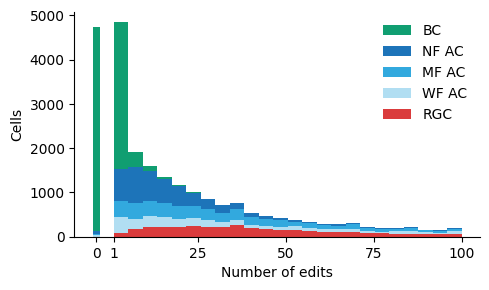

In [20]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

fieldkey = 'n_edits_plotting'

df_plot['n_edits_plotting']=df_plot['n_edits'].copy()
df_plot.loc[df_plot['n_edits']==0,'n_edits_plotting'] = -5
    
celltype_labels = ['RGC', 'WF AC', 'MF AC', 'NF AC',  'BC']
# celltype_labels_legend = [f'{c} (n={int(sum(df_plot.class_incl_subclasses==c))})' for c in celltype_labels]
celltype_labels_legend = [f'{c}' for c in celltype_labels]
celltype_colors = ['#DA3B3C','#b1def2','#32A9DE','#1D74B9','#109e71']
data=[]
for celltype in celltype_labels:
    data.append(df_plot[fieldkey][df_plot['class_incl_subclasses']==celltype].values)

ax.hist(
    data,
    bins=np.linspace(-5,-3,2),
    stacked=True,
    color=celltype_colors,
     edgecolor='none',
)

ax.hist(
    data,
    bins=np.linspace(1,100,25),
    stacked=True,
    color=celltype_colors,
    label=celltype_labels_legend,
     edgecolor='none'
)

ax.set_xticks(ticks=[-4,1,25,50,75,100],labels=[0,1,25,50,75,100])

ax.set_xlabel('Number of edits')
ax.set_ylabel('Cells')
#reverse legend color order for a better visual match
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False)
    

sns.despine()
plt.tight_layout()
fig.savefig(f'{fig_dir}/proofreading-n_edits.svg',dpi=300)

Ignoring 7010 cells that are nan (0 or 1 edit) or have 0 edit time (rare cases)


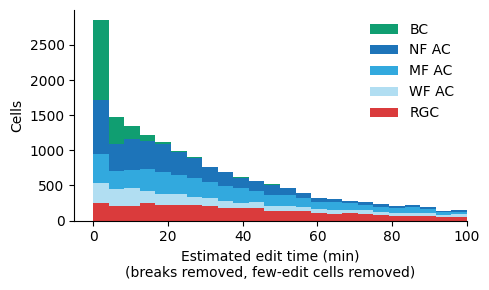

In [21]:
fig,ax = plt.subplots(1,1,figsize=(5,3))
fieldkey = 'edittime_nobreaks_min'

df_plot2 = df_plot.copy()
isna=df_plot2[fieldkey].isna()
iszero=df_plot2[fieldkey]==0
ignore_idx = np.logical_or(isna,iszero)
df_plot2 = df_plot2.loc[~ignore_idx,:]
print(f'Ignoring {sum(ignore_idx)} cells that are nan (0 or 1 edit) or have 0 edit time (rare cases)')

celltype_labels = ['RGC', 'WF AC', 'MF AC', 'NF AC',  'BC']
#celltype_labels_legend = [f'{c} (n={int(sum(df_plot2.class_incl_subclasses==c))})' for c in celltype_labels]
celltype_labels_legend = [f'{c}' for c in celltype_labels]
celltype_colors = ['#DA3B3C','#b1def2','#32A9DE','#1D74B9','#109e71']

data=[]
for celltype in celltype_labels:
    data.append(df_plot2[fieldkey][df_plot2['class_incl_subclasses']==celltype].values)

ax.hist(
    data,
    bins=np.linspace(0,100,25),
    stacked=True,
    color=celltype_colors,
    label=celltype_labels_legend,
    edgecolor='none'
)

ax.set_xlim(right=100)
ax.set_xlabel('Estimated edit time (min)\n(breaks removed, few-edit cells removed)')
ax.set_ylabel('Cells')
#reverse legend color order for a better visual match
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False)
    
sns.despine()
plt.tight_layout()
fig.savefig(f'{fig_dir}/proofreading-edittime.svg',dpi=300)

### Example cells

Final example links:

BCs
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6344704827326464

ACs
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6005888832765952

RGCs 
https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/6360739215310848
